# Análise Exploratória de Dados — Olist (Projeto Aplicado I, Etapa 2)

**Aluno:** Felipe Passador Leite — RA 10401969
**Organização:** Olist (marketplace brasileiro de e-commerce)
**Problema de pesquisa:** atrasos na entrega dos pedidos impactam a satisfação do cliente?

Este notebook segue a estrutura de Análise Exploratória de Dados (AED) apresentada na Aula 2
da disciplina: dimensões do dataset, tipos de dados, tratamento inicial, valores ausentes,
medidas de posição e dispersão, distribuição e frequência, outliers e correlações.


## 1. Importação das bibliotecas

Bibliotecas de análise de dados (pandas, numpy) e de visualização (matplotlib, seaborn).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual padrão dos gráficos deste notebook
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 50)


## 2. Carregamento dos dados

Carregamos as 9 tabelas do dataset "Brazilian E-Commerce Public Dataset by Olist",
armazenadas na pasta `dados/` do repositório do projeto.

In [2]:
caminho = "dados/"

customers = pd.read_csv(caminho + "olist_customers_dataset.csv")
geolocation = pd.read_csv(caminho + "olist_geolocation_dataset.csv")
order_items = pd.read_csv(caminho + "olist_order_items_dataset.csv")
order_payments = pd.read_csv(caminho + "olist_order_payments_dataset.csv")
order_reviews = pd.read_csv(caminho + "olist_order_reviews_dataset.csv")
orders = pd.read_csv(caminho + "olist_orders_dataset.csv")
products = pd.read_csv(caminho + "olist_products_dataset.csv")
sellers = pd.read_csv(caminho + "olist_sellers_dataset.csv")
category_translation = pd.read_csv(caminho + "product_category_name_translation.csv")

tabelas = {
    "customers": customers,
    "geolocation": geolocation,
    "order_items": order_items,
    "order_payments": order_payments,
    "order_reviews": order_reviews,
    "orders": orders,
    "products": products,
    "sellers": sellers,
    "category_translation": category_translation,
}
print("Tabelas carregadas:", list(tabelas.keys()))


Tabelas carregadas: ['customers', 'geolocation', 'order_items', 'order_payments', 'order_reviews', 'orders', 'products', 'sellers', 'category_translation']


## 3. Dimensões e tipos de dados

Para cada tabela, verificamos o número de linhas (exemplares), número de colunas (dimensões)
e o tipo de dado de cada coluna — primeira pergunta de qualquer Análise Exploratória de Dados.

In [3]:
for nome, df in tabelas.items():
    print(f"--- {nome} ---")
    print(f"Linhas: {df.shape[0]:,} | Colunas: {df.shape[1]}")
    print(df.dtypes.to_string())
    print()


--- customers ---
Linhas: 99,441 | Colunas: 5
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str

--- geolocation ---
Linhas: 1,000,163 | Colunas: 5
geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                   str
geolocation_state                  str

--- order_items ---
Linhas: 112,650 | Colunas: 7
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64

--- order_payments ---
Linhas: 103,886 | Colunas: 5
order_id                    str
payment_sequential        int64
payment_type                str
payment_installments      int64
payment_value           float64

--- order_reviews ---
Linhas: 99,224 | Colunas: 7
review

## 4. Tratamento inicial dos dados

As colunas de data na tabela `orders` estão como texto (object); convertemos para o tipo
datetime, o que é necessário antes de calcular prazos de entrega.

Em seguida, criamos duas variáveis novas (feature engineering), centrais para o problema
de pesquisa deste projeto:

- **atraso_entrega_dias**: diferença, em dias, entre a data real de entrega ao cliente e a
  data estimada. Valores positivos indicam atraso; valores negativos indicam entrega
  adiantada.
- **tempo_entrega_dias**: tempo total, em dias, entre a compra e a entrega ao cliente.


In [4]:
colunas_data = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for c in colunas_data:
    orders[c] = pd.to_datetime(orders[c])

orders["atraso_entrega_dias"] = (
    orders["order_delivered_customer_date"] - orders["order_estimated_delivery_date"]
).dt.days

orders["tempo_entrega_dias"] = (
    orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
).dt.days

orders[["order_id", "order_estimated_delivery_date", "order_delivered_customer_date",
        "atraso_entrega_dias", "tempo_entrega_dias"]].head()


,order_id,order_estimated_delivery_date,order_delivered_customer_date,atraso_entrega_dias,tempo_entrega_dias
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-18,2017-10-10 21:25:13,-8.0,8.0
1,53cdb2fc8bc7dce0b6741e2150273451,2018-08-13,2018-08-07 15:27:45,-6.0,13.0
2,47770eb9100c2d0c44946d9cf07ec65d,2018-09-04,2018-08-17 18:06:29,-18.0,9.0
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-12-15,2017-12-02 00:28:42,-13.0,13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-26,2018-02-16 18:17:02,-10.0,2.0


## 5. Valores ausentes (missing values)

Contagem de valores nulos por coluna, nas tabelas mais relevantes para o problema de
pesquisa (`orders` e `order_reviews`).

In [5]:
print("Valores nulos — orders:")
print(orders.isnull().sum()[orders.isnull().sum() > 0])
print()
print("Valores nulos — order_reviews:")
print(order_reviews.isnull().sum()[order_reviews.isnull().sum() > 0])


Valores nulos — orders:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
atraso_entrega_dias              2965
tempo_entrega_dias               2965
dtype: int64

Valores nulos — order_reviews:
review_comment_title      87656
review_comment_message    58247
dtype: int64


In [6]:
# Quantos pedidos não têm data de entrega registrada (não chegaram ao cliente)?
pedidos_sem_entrega = orders["order_delivered_customer_date"].isnull().sum()
total_pedidos = len(orders)
print(f"Pedidos sem data de entrega registrada: {pedidos_sem_entrega} de {total_pedidos} "
      f"({pedidos_sem_entrega/total_pedidos:.2%})")
print()
print("Distribuição do status desses pedidos sem entrega registrada:")
print(orders.loc[orders["order_delivered_customer_date"].isnull(), "order_status"].value_counts())


Pedidos sem data de entrega registrada: 2965 de 99441 (2.98%)

Distribuição do status desses pedidos sem entrega registrada:
order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64


## 6. Medidas de posição e dispersão

Para as variáveis numéricas centrais do problema de pesquisa (`atraso_entrega_dias`,
`tempo_entrega_dias` e `review_score`), calculamos as medidas de tendência central
(média, mediana, moda), as separatrizes (quartis) e as medidas de dispersão
(variância, desvio padrão e coeficiente de variação).

In [7]:
def resumo_estatistico(serie, nome):
    s = serie.dropna()
    media = s.mean()
    mediana = s.median()
    moda = s.mode().iloc[0] if not s.mode().empty else np.nan
    variancia = s.var()
    desvio = s.std()
    cv = (desvio / media * 100) if media != 0 else np.nan
    q1, q2, q3 = s.quantile([0.25, 0.5, 0.75])
    print(f"--- {nome} ---")
    print(f"Contagem (n)        : {s.shape[0]:,}")
    print(f"Média               : {media:.2f}")
    print(f"Mediana             : {mediana:.2f}")
    print(f"Moda                : {moda:.2f}")
    print(f"Mínimo              : {s.min():.2f}")
    print(f"Máximo              : {s.max():.2f}")
    print(f"Q1 (25%)            : {q1:.2f}")
    print(f"Q3 (75%)            : {q3:.2f}")
    print(f"Variância           : {variancia:.2f}")
    print(f"Desvio padrão       : {desvio:.2f}")
    print(f"Coeficiente de var. : {cv:.2f}%")
    print()

resumo_estatistico(orders["atraso_entrega_dias"], "Atraso de entrega (dias)")
resumo_estatistico(orders["tempo_entrega_dias"], "Tempo total de entrega (dias)")
resumo_estatistico(order_reviews["review_score"], "Nota de avaliação (review_score)")


--- Atraso de entrega (dias) ---
Contagem (n)        : 96,476
Média               : -11.88
Mediana             : -12.00
Moda                : -14.00
Mínimo              : -147.00
Máximo              : 188.00
Q1 (25%)            : -17.00
Q3 (75%)            : -7.00
Variância           : 103.71
Desvio padrão       : 10.18
Coeficiente de var. : -85.75%

--- Tempo total de entrega (dias) ---
Contagem (n)        : 96,476
Média               : 12.09
Mediana             : 10.00
Moda                : 7.00
Mínimo              : 0.00
Máximo              : 209.00
Q1 (25%)            : 6.00
Q3 (75%)            : 15.00
Variância           : 91.24
Desvio padrão       : 9.55
Coeficiente de var. : 78.98%



--- Nota de avaliação (review_score) ---
Contagem (n)        : 99,224
Média               : 4.09
Mediana             : 5.00
Moda                : 5.00
Mínimo              : 1.00
Máximo              : 5.00
Q1 (25%)            : 4.00
Q3 (75%)            : 5.00
Variância           : 1.82
Desvio padrão       : 1.35
Coeficiente de var. : 32.98%



## 7. Distribuição e frequência

Visualizamos a distribuição do atraso de entrega e a frequência das notas de avaliação.

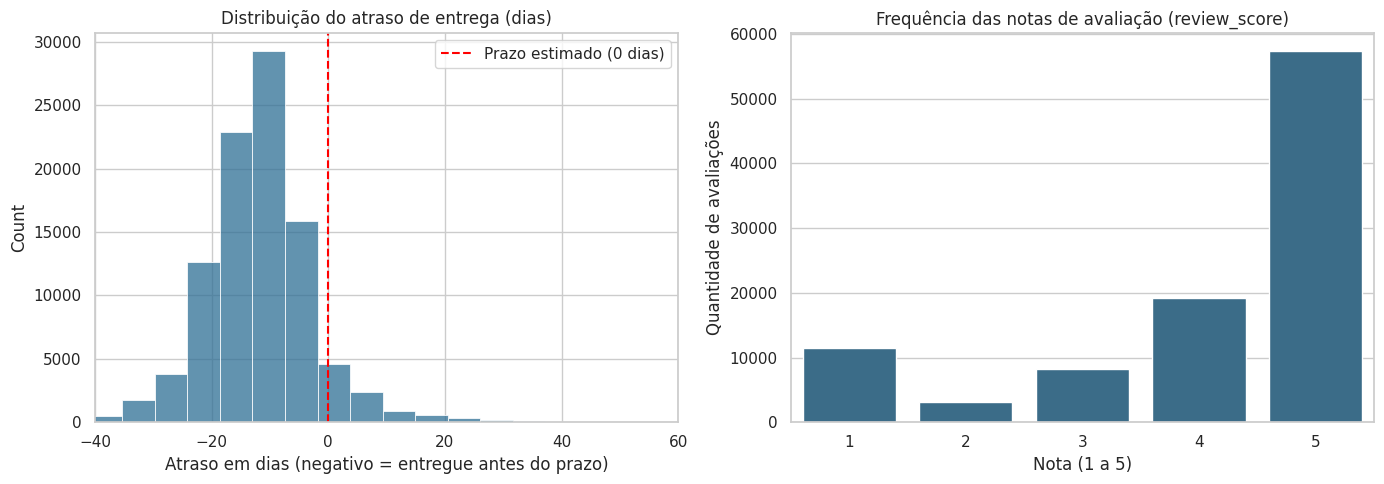

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(orders["atraso_entrega_dias"].dropna(), bins=60, ax=axes[0], color="#2e6f95")
axes[0].axvline(0, color="red", linestyle="--", label="Prazo estimado (0 dias)")
axes[0].set_title("Distribuição do atraso de entrega (dias)")
axes[0].set_xlabel("Atraso em dias (negativo = entregue antes do prazo)")
axes[0].set_xlim(-40, 60)
axes[0].legend()

sns.countplot(x="review_score", data=order_reviews, ax=axes[1], color="#2e6f95")
axes[1].set_title("Frequência das notas de avaliação (review_score)")
axes[1].set_xlabel("Nota (1 a 5)")
axes[1].set_ylabel("Quantidade de avaliações")

plt.tight_layout()
plt.savefig("distribuicao_atraso_reviews.png", dpi=120)
plt.show()


In [9]:
# Frequência relativa dos status de pedido
print("Frequência dos status de pedido (order_status):")
print(orders["order_status"].value_counts())
print()
print("Frequência relativa (%):")
print((orders["order_status"].value_counts(normalize=True) * 100).round(2))


Frequência dos status de pedido (order_status):
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Frequência relativa (%):
order_status
delivered      97.02
shipped         1.11
canceled        0.63
unavailable     0.61
invoiced        0.32
processing      0.30
created         0.01
approved        0.00
Name: proportion, dtype: float64


## 8. Outliers (valores anômalos)

Usamos o método do intervalo interquartil (IQR) para identificar outliers na variável de
atraso de entrega, e um boxplot para visualizá-los.

In [10]:
serie = orders["atraso_entrega_dias"].dropna()
q1, q3 = serie.quantile([0.25, 0.75])
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers = serie[(serie < limite_inferior) | (serie > limite_superior)]
print(f"Limite inferior (IQR): {limite_inferior:.1f} dias")
print(f"Limite superior (IQR): {limite_superior:.1f} dias")
print(f"Quantidade de outliers: {len(outliers):,} ({len(outliers)/len(serie):.2%} dos pedidos com data de entrega)")
print(f"Maior atraso observado: {serie.max():.0f} dias")


Limite inferior (IQR): -32.0 dias
Limite superior (IQR): 8.0 dias
Quantidade de outliers: 4,301 (4.46% dos pedidos com data de entrega)
Maior atraso observado: 188 dias


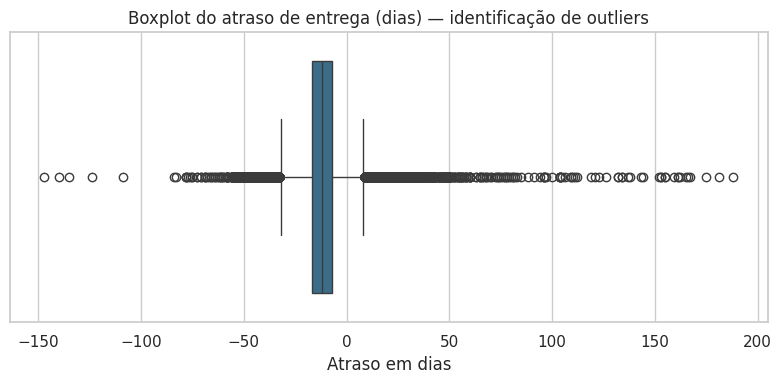

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x=orders["atraso_entrega_dias"].dropna(), ax=ax, color="#2e6f95")
ax.set_title("Boxplot do atraso de entrega (dias) — identificação de outliers")
ax.set_xlabel("Atraso em dias")
plt.tight_layout()
plt.savefig("boxplot_atraso.png", dpi=120)
plt.show()


## 9. Correlação entre atraso de entrega e satisfação do cliente

Esta seção aborda diretamente o problema de pesquisa do projeto: existe relação entre
atraso na entrega e a nota de avaliação dada pelo cliente?

Para isso, juntamos (merge) a tabela `orders` (que contém o atraso calculado) com a tabela
`order_reviews` (que contém a nota), por meio da chave `order_id`.

In [12]:
orders_reviews = orders.merge(order_reviews[["order_id", "review_score"]], on="order_id", how="inner")

correlacao = orders_reviews[["atraso_entrega_dias", "review_score"]].corr().iloc[0, 1]
print(f"Correlação entre atraso de entrega e nota de avaliação: {correlacao:.3f}")
print("(valores negativos indicam que, quanto maior o atraso, menor tende a ser a nota)")


Correlação entre atraso de entrega e nota de avaliação: -0.267
(valores negativos indicam que, quanto maior o atraso, menor tende a ser a nota)


Atraso médio de entrega (dias), por nota de avaliação:
review_score
1    -4.06
2    -8.63
3   -10.77
4   -12.38
5   -13.39
Name: atraso_entrega_dias, dtype: float64


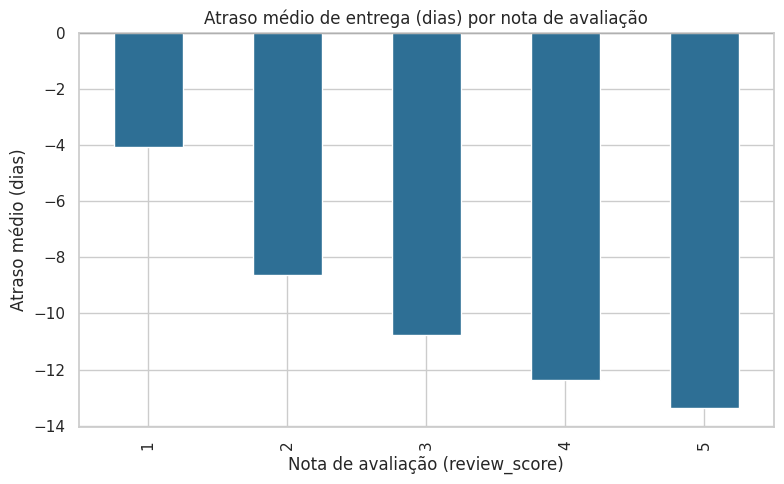

In [13]:
media_atraso_por_nota = orders_reviews.groupby("review_score")["atraso_entrega_dias"].mean()
print("Atraso médio de entrega (dias), por nota de avaliação:")
print(media_atraso_por_nota.round(2))

fig, ax = plt.subplots(figsize=(8, 5))
media_atraso_por_nota.plot(kind="bar", ax=ax, color="#2e6f95")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Atraso médio de entrega (dias) por nota de avaliação")
ax.set_xlabel("Nota de avaliação (review_score)")
ax.set_ylabel("Atraso médio (dias)")
plt.tight_layout()
plt.savefig("atraso_medio_por_nota.png", dpi=120)
plt.show()


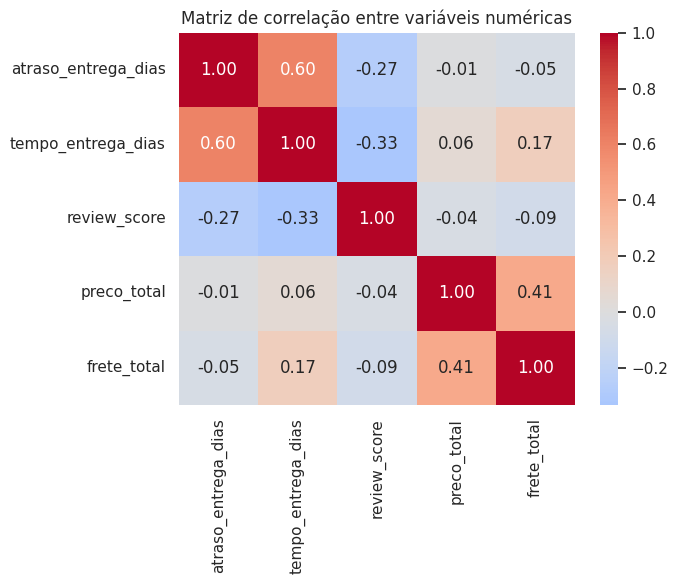

In [14]:
# Matriz de correlação incluindo outras variáveis numéricas de interesse (preço e frete)
itens_pedido = order_items.groupby("order_id").agg(
    preco_total=("price", "sum"),
    frete_total=("freight_value", "sum"),
).reset_index()

base_correlacao = orders_reviews.merge(itens_pedido, on="order_id", how="left")
colunas_num = ["atraso_entrega_dias", "tempo_entrega_dias", "review_score", "preco_total", "frete_total"]
matriz_corr = base_correlacao[colunas_num].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Matriz de correlação entre variáveis numéricas")
plt.tight_layout()
plt.savefig("matriz_correlacao.png", dpi=120)
plt.show()


## 10. Síntese dos achados desta etapa

- O dataset contém **99.441 pedidos**, dos quais aproximadamente **3%** não possuem data de
  entrega ao cliente registrada (em sua maioria com status diferente de "delivered").
- A maior parte dos pedidos é entregue **antes** da data estimada (atraso médio negativo),
  mas existe uma cauda de pedidos com atrasos consideráveis, identificados como outliers
  pelo método do IQR.
- A correlação entre atraso de entrega e nota de avaliação é **negativa**, confirmando a
  hipótese do problema de pesquisa: quanto maior o atraso, menor tende a ser a nota dada
  pelo cliente.
- O atraso médio de entrega cresce de forma visível conforme a nota cai de 5 para 1,
  reforçando essa relação.

Estes resultados serão detalhados, com os valores numéricos exatos obtidos na execução
deste notebook, na seção "Análise Exploratória de Dados" do documento da Etapa 2.
